<a href="https://colab.research.google.com/github/janani26121992/AI-Projects/blob/main/AI_Regressionproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Title:**

***"Power Plant Energy Output Prediction using Artificial Neural Networks (ANN)"***

This project predicts the power energy output of a combined cycle power plant using environmental sensor data such as temperature, pressure, humidity, and vacuum.

Model performance:
MAE = 3.57
R2 Score = 0.93

# Problem Statement

### ***Build an ANN model that predicts the power enegy generated by the powerplant by taking various sensor readings into consideration.***

**Data Gathering**

In [160]:
import pandas as pd
path=r"https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/PowerPlant.csv"
df=pd.read_csv(path)
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


**Basic Quality Checks**

In [161]:
df.shape

(9568, 5)

In [162]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [163]:
df.duplicated().sum()

np.int64(41)

In [164]:
df=df.drop_duplicates()

In [165]:
df.duplicated().sum()

np.int64(0)

In [166]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='object')

In [167]:
df = df.rename(columns={
    "AT": "Ambient_Temperature",
    "V": "Exhaust_Vacuum",
    "AP": "Ambient_Pressure",
    "RH": "Relative_Humidity",
    "PE": "Power_Output"
})

In [168]:
df.columns

Index(['Ambient_Temperature', 'Exhaust_Vacuum', 'Ambient_Pressure',
       'Relative_Humidity', 'Power_Output'],
      dtype='object')

# **Separate X and Y features**

In [169]:
X=df.drop(columns='Power_Output')
Y=df[['Power_Output']]

In [170]:
X.head()

,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


# **Feature Engineering**

In [171]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
pre=make_pipeline(
    SimpleImputer(strategy='median'),
    StandardScaler()
).set_output(transform='pandas')
X_pre=pre.fit_transform(X)
X_pre


,Ambient_Temperature,Exhaust_Vacuum,Ambient_Pressure,Relative_Humidity
0,-1.520448,-1.066041,-0.403535,1.141599
1,0.534897,0.330813,-0.309262,0.059223
2,1.354348,0.205475,-1.024725,-2.151400
3,-0.079020,-0.362884,-1.012941,0.236538
4,-1.055645,-1.074713,0.655349,1.633837
...,...,...,...,...
9563,-0.609648,-0.423583,-0.241925,-0.027724
9564,1.847362,1.864831,-0.494441,-0.932100
9565,-0.492776,-0.863450,0.162101,0.364561
9566,-0.269777,0.439598,0.899448,1.459261


# **Split the data into training and testing**

In [172]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X_pre,Y,train_size=0.75,random_state=42)

# **Model** **Building**

In [173]:
from keras.models import Sequential
from keras.layers import Input,Dense,Dropout,BatchNormalization
from keras.callbacks import EarlyStopping

In [174]:
# Intialize the model
model = Sequential()

# Add the Input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the Hidden layer 1
model.add(Dense(units=128,activation='relu'))
# Add the batch normalisation
model.add(BatchNormalization())
# Add the Dropout layer
model.add(Dropout(rate=0.3))

# Add the Hidden layer 2
model.add(Dense(units=128,activation='relu'))
# Add the batch normalisation
model.add(BatchNormalization())
# Add the Dropout layer
model.add(Dropout(rate=0.3))

# Add the Output layer
model.add(Dense(units=ytrain.shape[1],activation='linear'))

# Early Stopping

In [175]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

earlystop = EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)

In [176]:
nuralnetwork=model.fit(xtrain,ytrain,validation_split=0.2,epochs=300,batch_size=32,callbacks=[earlystop])

Epoch 1/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 204740.7031 - mae: 452.2982 - val_loss: 200981.3438 - val_mae: 448.1333
Epoch 2/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 192529.8438 - mae: 438.6661 - val_loss: 180550.8594 - val_mae: 424.8751
Epoch 3/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 164069.2812 - mae: 404.7502 - val_loss: 144903.2812 - val_mae: 380.6299
Epoch 4/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 125029.0859 - mae: 353.0227 - val_loss: 103884.2188 - val_mae: 322.2749
Epoch 5/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 84201.0547 - mae: 289.1443 - val_loss: 65008.8398 - val_mae: 254.9076
Epoch 6/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 49346.2109 - mae: 220.5467 - val_loss: 35091.5938 - val_mae: 187.2552
Epoch 7/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 25051.8145 - mae: 155.7850 - val_loss: 15876.0947 - val_mae: 125.9078
Epoch 8/300
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 10728.7568 - m

# **Learning Curve**

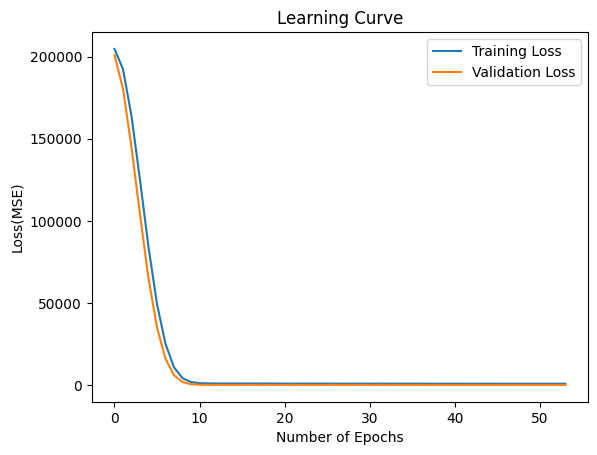

In [188]:
import matplotlib.pyplot as plt
plt.plot(nuralnetwork.history['loss'],label='Training Loss')
plt.plot(nuralnetwork.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss(MSE)")
plt.legend()
plt.show()

In [178]:
model.evaluate(xtrain,ytrain)

224/224 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.8305 - mae: 3.6101


[20.830495834350586, 3.6101198196411133]

In [179]:
model.evaluate(xtest,ytest)

75/75 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 20.3000 - mae: 3.5741


[20.299959182739258, 3.5740904808044434]

In [181]:
ypred = model.predict(xtest)
ypred


75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


array([[435.05035],
       [481.16675],
       [482.0608 ],
       ...,
       [448.59665],
       [477.40424],
       [453.4795 ]], dtype=float32)

In [186]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

ypred = model.predict(xtest)

mae = mean_absolute_error(ytest, ypred)
mse = mean_squared_error(ytest, ypred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ypred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE: 3.574089288711548
MSE: 20.299959182739258
RMSE: 4.505547600762782
R2 Score: 0.9319401383399963


# **Predicted vs Actual Plot**

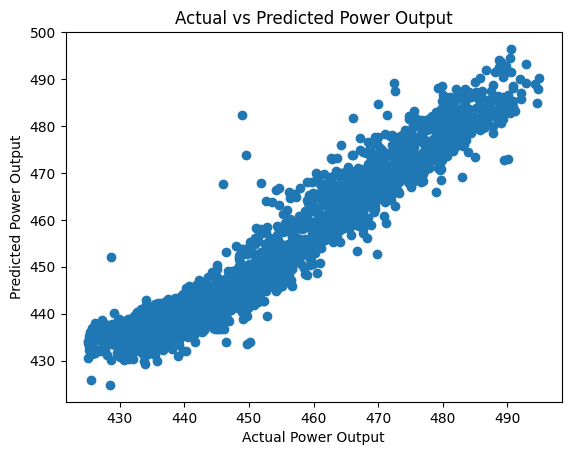

In [187]:
import matplotlib.pyplot as plt

plt.scatter(ytest, ypred)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Power Output")
plt.show()

# Since the points lie close to the diagonal pattern, it shows the model predictions are close to actual values and the model has good accuracy.

## **Conclusion**

The Artificial Neural Network model was successfully developed to predict the energy output of a power plant using environmental variables such as ambient temperature, exhaust vacuum, ambient pressure, and relative humidity.

The model achieved a Mean Absolute Error (MAE) of 3.57, Mean Squared Error (MSE) of 20.30, Root Mean Squared Error (RMSE) of 4.51, and an R² score of 0.93.

These results indicate that the ANN model provides accurate predictions and can explain approximately 93% of the variance in power output. The model demonstrates the effectiveness of neural networks for modeling complex relationships in energy systems and can assist in optimizing power plant operations.

# **Save the model**

In [183]:
model.save("power_plant_ann_model.keras")

In [184]:
from keras.models import load_model
m1 = load_model("/content/power_plant_ann_model.keras")
m1.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (None, 128)            │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,893 (210.52 KB)

 Trainable params: 17,793 (69.50 KB)

 Non-trainable params: 512 (2.00 KB)

 Optimizer params: 35,588 (139.02 KB)